<a href="https://colab.research.google.com/github/Uwais-ur-Rehman/ML-Project/blob/main/Outlier__detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/Salary Data.csv')

In [ ]:
df.sample(3)

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
321,32.0,Male,Bachelor's,Junior Financial Advisor,4.0,65000.0
134,27.0,Male,Bachelor's,Junior Sales Representative,1.0,35000.0
318,30.0,Female,Bachelor's,Junior HR Coordinator,2.0,40000.0


In [ ]:
df.describe()

,Age,Years of Experience,Salary
count,373.000000,373.000000,373.000000
mean,37.431635,10.030831,100577.345845
std,7.069073,6.557007,48240.013482
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.000000,9.000000,95000.000000
75%,44.000000,15.000000,140000.000000
max,53.000000,25.000000,250000.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


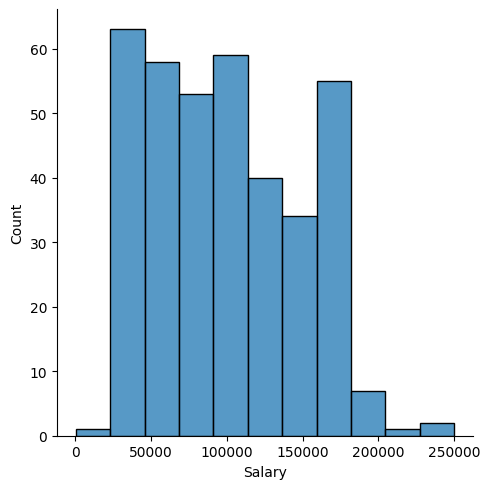

In [ ]:
sns.displot(df['Salary'])
plt.show()

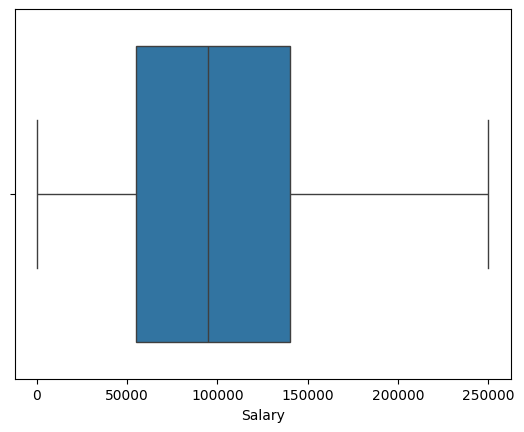

In [ ]:
sns.boxplot(x='Salary',data=df)
plt.show()

**Outlier Removal**

In [ ]:
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing(as_frame=True)
df = data.frame

In [ ]:
df.sample(3)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
8424,3.1656,27.0,3.993711,1.106020,3340.0,3.000898,33.93,-118.36,2.045
13115,7.0326,10.0,6.670968,0.987097,478.0,3.083871,38.37,-121.13,2.411
7995,4.0781,36.0,5.605263,0.973684,699.0,2.627820,33.85,-118.15,2.173


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [ ]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


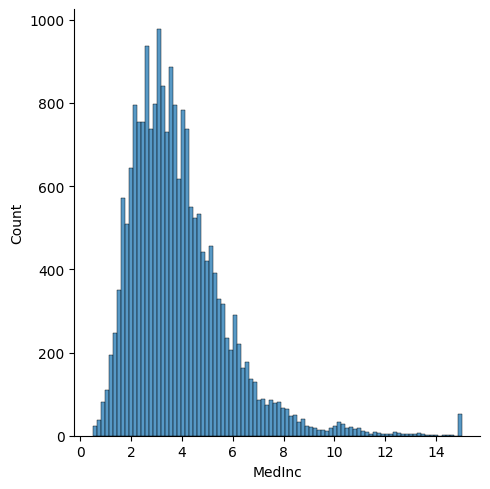

In [ ]:
sns.displot(df['MedInc'])
plt.show()

In [ ]:
df.shape

(20640, 9)

In [ ]:
numerical_cols= df.select_dtypes(include='number').columns
for col in numerical_cols:
  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)
  IQR=Q3-Q1
  lower_bound=Q1-1.5*IQR
  upper_bound=Q3+1.5*IQR

  outlier= ((df[col]<lower_bound) | (df[col]>upper_bound)).sum()
  print(f'{col}:{outlier}')

  df = df[(df[col] >= lower_bound) &(df[col] <= upper_bound)]



MedInc:681
HouseAge:0
AveRooms:439
AveBedrms:1116
Population:1063
AveOccup:528
Latitude:0
Longitude:0
MedHouseVal:581


In [ ]:
df.shape

(16232, 9)

In [ ]:
print(lower_bound)
print(upper_bound)

-0.8759999999999999
4.676


In [ ]:
numerical_cols


Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

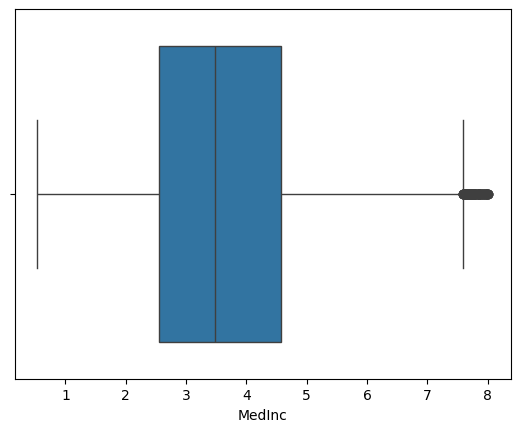

In [ ]:
sns.boxplot(x='MedInc',data=df)
plt.show()

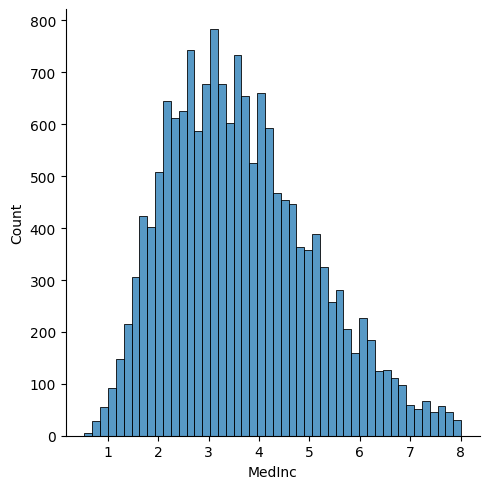

In [ ]:
sns.displot(df['MedInc'])
plt.show()